2.1 理论计算题

1. 非线性激活函数的重要性

设隐藏层输出为：
h = W1 x + b1

输出层输出为：
o = W2 h + b2

代入得：
o = W2 (W1 x + b1) + b2 = (W2 W1) x + (W2 b1 + b2)

因此等价于单层神经网络：
W' = W2 W1, b' = W2 b1 + b2


2. 激活函数性质分析

Sigmoid 函数：
sigma(x) = 1 / (1 + e^{-x})

Sigmoid 导数：
sigma'(x) = sigma(x) (1 - sigma(x))

tanh 函数：
tanh(x) = (e^{x} - e^{-x}) / (e^{x} + e^{-x})

tanh 导数：
tanh'(x) = 1 - tanh^2(x)


3.1 理论计算题

1. 过拟合与欠拟合

训练误差：模型在训练集上的误差。
泛化误差：模型在未见过的测试集上的误差。

当训练误差极低但泛化误差很高时，模型处于过拟合状态。

缓解方法：降低模型复杂度（减少层数、神经元数），使用正则化（L2、Dropout），增加训练数据，早停等。


2. K 折交叉验证

步骤1：将数据集随机划分为 K 个大小相等的子集。
步骤2：对每个子集 i：
      将第 i 个子集作为验证集。
      其余 K-1 个子集作为训练集。
      训练模型并计算验证误差。
步骤3：计算 K 次验证误差的平均值作为最终评估指标。


4.1 理论计算题

1. 梯度消失与梯度爆炸

深层网络的梯度包含多层矩阵连乘项：乘积从i=t到d-1 of (偏h^{i+1}/偏h^{i})

梯度爆炸：当权重矩阵的谱半径大于1且激活函数导数在大部分区域大于1（如无约束线性激活）时，连乘结果指数级增长。

梯度消失：当权重矩阵的谱半径小于1或激活函数导数在大部分区域小于1（如Sigmoid导数小于等于0.25）时，连乘结果指数级衰减趋近于0。


2. ReLU 缓解梯度消失的原因

ReLU 函数在正半轴的导数为1，负半轴导数为0。正向传播时梯度不会因激活函数导数而衰减（只要神经元激活），避免了 Sigmoid 类函数的饱和区导致的梯度消失问题。


5.1 理论计算题

1. 协变量偏移与标签偏移

协变量偏移：特征分布改变 p(x) 不等于 q(x)，但条件标签分布不变 p(y|x) = q(y|x)。
例子：医疗诊断中训练数据来自年轻人群，测试数据来自老年人群（特征分布变化，但病情与症状关系不变）。

标签偏移：标签分布改变 p(y) 不等于 q(y)，但特征条件分布不变 p(x|y) = q(x|y)。
例子：疫情前后疾病发病率变化（标签分布变），但症状表现与疾病的关系不变。

区别：偏移的变量不同（特征 vs 标签）。
联系：都属于分布偏移，需要调整模型或采样权重来适应新环境。

Epoch 1, Loss 1.0552, Train Acc 0.6298, Test Acc 0.7528
Epoch 2, Loss 0.6040, Train Acc 0.7883, Test Acc 0.7882
Epoch 3, Loss 0.5217, Train Acc 0.8159, Test Acc 0.7982
Epoch 4, Loss 0.4807, Train Acc 0.8312, Test Acc 0.8107
Epoch 5, Loss 0.4538, Train Acc 0.8400, Test Acc 0.8362


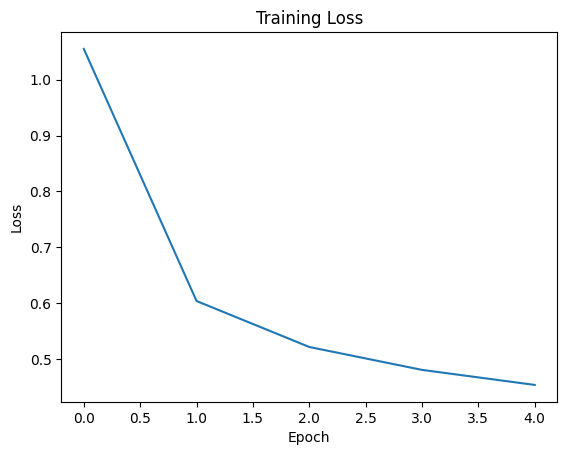

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

batch_size = 256
lr = 0.1
epochs = 5

transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

num_inputs = 784
num_hidden = 256
num_outputs = 10

W1 = (torch.randn(num_inputs, num_hidden) * 0.01).requires_grad_()
b1 = torch.zeros(num_hidden, requires_grad=True)

W2 = (torch.randn(num_hidden, num_outputs) * 0.01).requires_grad_()
b2 = torch.zeros(num_outputs, requires_grad=True)

def relu(X):
    return torch.clamp(X, min=0)

def net(X):
    X = X.reshape(-1, 784)
    H = relu(torch.matmul(X, W1) + b1)
    return torch.matmul(H, W2) + b2

def cross_entropy(y_hat, y):
    y_hat = y_hat - y_hat.max(dim=1, keepdim=True).values
    y_hat = torch.softmax(y_hat, dim=1)
    return -torch.log(y_hat[range(len(y)), y]).mean()

train_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):

    total_loss = 0
    total_correct = 0
    total = 0

    for X, y in train_loader:

        y_hat = net(X)
        loss = cross_entropy(y_hat, y)

        loss.backward()

        with torch.no_grad():
            for param in [W1, b1, W2, b2]:
                param -= lr * param.grad
                param.grad.zero_()

        total_loss += loss.item()
        total_correct += (y_hat.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = total_correct / total

    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X, y in test_loader:
            y_hat = net(X)
            test_correct += (y_hat.argmax(dim=1) == y).sum().item()
            test_total += y.size(0)

    test_acc = test_correct / test_total

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(
        f'Epoch {epoch+1}, '
        f'Loss {train_loss:.4f}, '
        f'Train Acc {train_acc:.4f}, '
        f'Test Acc {test_acc:.4f}'
    )

plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

No Regularization
1 1.0411206473695471 0.7024486184120178
2 0.5967935869034301 0.5768410429358483
3 0.5200247890137611 0.5281238272786141
4 0.476447916411339 0.4856072083115578
5 0.45312751848646937 0.4733575753867626
6 0.42992157302004225 0.44907320067286494
7 0.4149351940510121 0.531249251961708
8 0.40079977956223994 0.44058138951659204
9 0.3914887232983366 0.42839851453900335
10 0.38181053127380127 0.570941711217165
Weight Decay
1 1.0419856449390978 0.7022786319255829
2 0.600231589408631 0.5484881646931171
3 0.526324100316839 0.5715387649834156
4 0.47911392031831945 0.5200011402368545
5 0.4561864972114563 0.4724166728556156
6 0.43296021768387327 0.47487521916627884
7 0.4222293718064085 0.45443404018878936
8 0.4067142502424565 0.42798081785440445
9 0.39502513789116067 0.4571217194199562
10 0.3832579257640433 0.45212234929203987
Dropout
1 1.0973087085054276 0.6916568621993064
2 0.6428066961308743 0.5945068314671517
3 0.5524602722614369 0.5060485012829303
4 0.5061587177692576 0.4796536

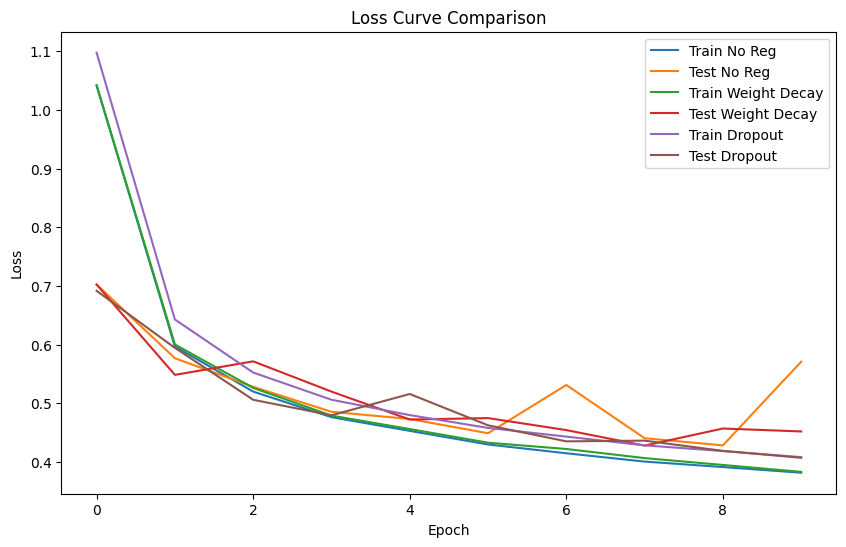

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

batch_size = 256
lr = 0.1
epochs = 10

transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

num_inputs = 784
num_hidden = 256
num_outputs = 10

def relu(X):
    return torch.clamp(X, min=0)

def dropout_layer(X, dropout, is_training):

    if dropout == 0:
        return X

    if not is_training:
        return X

    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

def cross_entropy(y_hat, y):

    y_hat = y_hat - y_hat.max(dim=1, keepdim=True).values
    y_hat = torch.softmax(y_hat, dim=1)

    return -torch.log(
        y_hat[range(len(y)), y]
    ).mean()

def train_model(weight_decay=0, dropout=0):

    W1 = (
        torch.randn(num_inputs, num_hidden) * 0.01
    ).requires_grad_()

    b1 = torch.zeros(
        num_hidden,
        requires_grad=True
    )

    W2 = (
        torch.randn(num_hidden, num_outputs) * 0.01
    ).requires_grad_()

    b2 = torch.zeros(
        num_outputs,
        requires_grad=True
    )

    train_losses = []
    test_losses = []

    for epoch in range(epochs):

        total_train_loss = 0

        for X, y in train_loader:

            X = X.reshape(-1, 784)

            H = relu(
                torch.matmul(X, W1) + b1
            )

            H = dropout_layer(
                H,
                dropout,
                True
            )

            y_hat = torch.matmul(H, W2) + b2

            loss = cross_entropy(
                y_hat,
                y
            )

            loss.backward()

            with torch.no_grad():

                W1 *= (
                    1 - lr * weight_decay
                )

                W2 *= (
                    1 - lr * weight_decay
                )

                for param in [
                    W1,
                    b1,
                    W2,
                    b2
                ]:

                    param -= (
                        lr * param.grad
                    )

                    param.grad.zero_()

            total_train_loss += loss.item()

        train_loss = (
            total_train_loss
            / len(train_loader)
        )

        total_test_loss = 0

        with torch.no_grad():

            for X, y in test_loader:

                X = X.reshape(-1, 784)

                H = relu(
                    torch.matmul(X, W1) + b1
                )

                H = dropout_layer(
                    H,
                    dropout,
                    False
                )

                y_hat = (
                    torch.matmul(H, W2)
                    + b2
                )

                loss = cross_entropy(
                    y_hat,
                    y
                )

                total_test_loss += (
                    loss.item()
                )

        test_loss = (
            total_test_loss
            / len(test_loader)
        )

        train_losses.append(
            train_loss
        )

        test_losses.append(
            test_loss
        )

        print(
            epoch + 1,
            train_loss,
            test_loss
        )

    return (
        train_losses,
        test_losses
    )

print('No Regularization')
train1, test1 = train_model(
    weight_decay=0,
    dropout=0
)

print('Weight Decay')
train2, test2 = train_model(
    weight_decay=1e-4,
    dropout=0
)

print('Dropout')
train3, test3 = train_model(
    weight_decay=0,
    dropout=0.5
)

plt.figure(figsize=(10,6))

plt.plot(
    train1,
    label='Train No Reg'
)

plt.plot(
    test1,
    label='Test No Reg'
)

plt.plot(
    train2,
    label='Train Weight Decay'
)

plt.plot(
    test2,
    label='Test Weight Decay'
)

plt.plot(
    train3,
    label='Train Dropout'
)

plt.plot(
    test3,
    label='Test Dropout'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(
    'Loss Curve Comparison'
)
plt.legend()
plt.show()

Part1: Gradient Vanishing
Layer 0: 6.942769e+03
Layer 2: 4.660972e+03
Layer 4: 3.852362e+03
Layer 6: 3.180131e+03
Layer 8: 2.546313e+03
Layer 10: 1.682509e+03
Layer 12: 1.478808e+03
Layer 14: 1.219769e+03
Layer 16: 9.460115e+02
Layer 18: 8.065331e+02
Layer 20: 6.565940e+02
Layer 22: 5.479471e+02
Layer 24: 5.018946e+02
Layer 26: 4.714638e+02
Layer 28: 4.536860e+02
Layer 30: 4.577455e+02
Layer 32: 4.312724e+02
Layer 34: 4.761320e+02
Layer 36: 5.227930e+02
Layer 38: 6.175865e+02


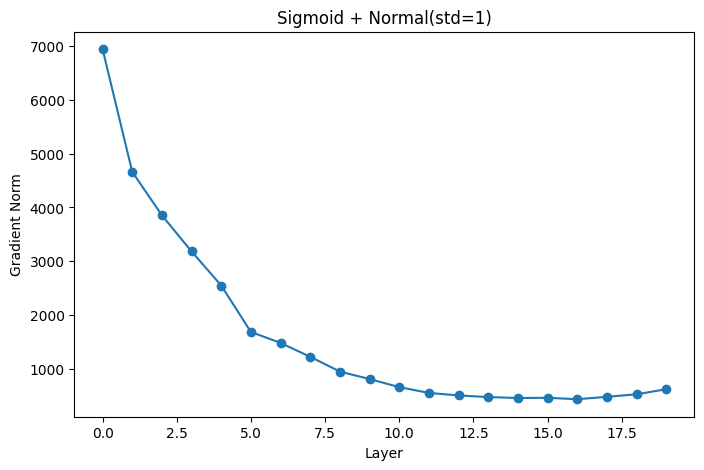


Part2: Gradient Explosion
Layer 0: nan
NaN Detected
Layer 2: inf
Layer 4: inf
Layer 6: inf
Layer 8: inf
Layer 10: inf
Layer 12: inf
Layer 14: inf
Layer 16: inf
Layer 18: inf
Layer 20: inf
Layer 22: inf
Layer 24: inf
Layer 26: inf
Layer 28: inf
Layer 30: inf
Layer 32: inf
Layer 34: inf
Layer 36: inf
Layer 38: nan
NaN Detected


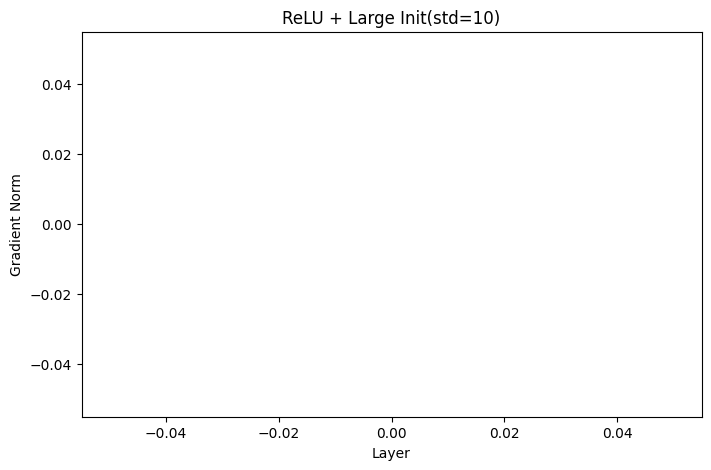


Part3: Xavier Repair
Layer 0: 5.111463e+00
Layer 2: 9.263190e+00
Layer 4: 1.146039e+01
Layer 6: 1.409610e+01
Layer 8: 1.506181e+01
Layer 10: 1.650537e+01
Layer 12: 1.876027e+01
Layer 14: 2.065161e+01
Layer 16: 2.342540e+01
Layer 18: 2.178141e+01
Layer 20: 1.883743e+01
Layer 22: 1.871856e+01
Layer 24: 1.949192e+01
Layer 26: 1.842611e+01
Layer 28: 1.819529e+01
Layer 30: 1.833224e+01
Layer 32: 1.484247e+01
Layer 34: 1.399789e+01
Layer 36: 1.413111e+01
Layer 38: 1.114958e+01


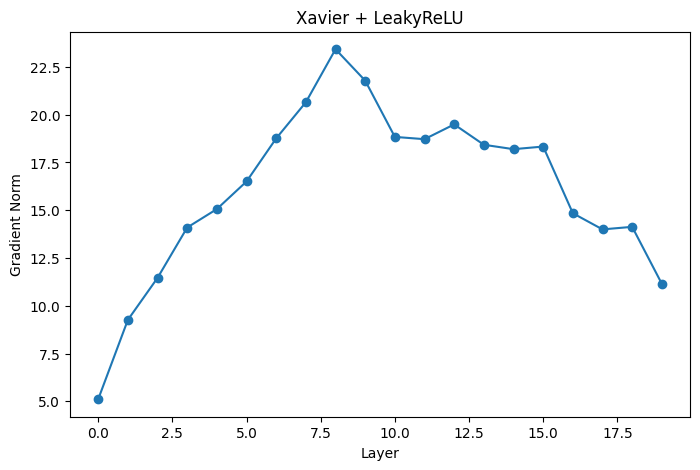

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math

input_dim = 256
hidden_dim = 256
num_layers = 20
batch_size = 64

X = torch.randn(batch_size, input_dim)

print('Part1: Gradient Vanishing')

layers = []

for i in range(num_layers):

    layers.append(
        nn.Linear(
            hidden_dim,
            hidden_dim
        )
    )

    layers.append(
        nn.Sigmoid()
    )

net1 = nn.Sequential(*layers)

for m in net1:

    if isinstance(m, nn.Linear):

        nn.init.normal_(
            m.weight,
            mean=0,
            std=1
        )

        nn.init.zeros_(
            m.bias
        )

y = net1(X).sum()

net1.zero_grad()
y.backward()

grad_norms1 = []

for i, m in enumerate(net1):

    if isinstance(m, nn.Linear):

        g = m.weight.grad.norm().item()
        grad_norms1.append(g)

        print(
            f'Layer {i}: {g:.6e}'
        )

plt.figure(figsize=(8,5))
plt.plot(
    grad_norms1,
    marker='o'
)
plt.xlabel('Layer')
plt.ylabel('Gradient Norm')
plt.title(
    'Sigmoid + Normal(std=1)'
)
plt.show()

print('\nPart2: Gradient Explosion')

layers = []

for i in range(num_layers):

    layers.append(
        nn.Linear(
            hidden_dim,
            hidden_dim
        )
    )

    layers.append(
        nn.ReLU()
    )

net2 = nn.Sequential(*layers)

for m in net2:

    if isinstance(m, nn.Linear):

        nn.init.normal_(
            m.weight,
            mean=0,
            std=10
        )

        nn.init.zeros_(
            m.bias
        )

y = net2(X).sum()

net2.zero_grad()
y.backward()

grad_norms2 = []

for i, m in enumerate(net2):

    if isinstance(m, nn.Linear):

        g = m.weight.grad.norm().item()

        grad_norms2.append(g)

        print(
            f'Layer {i}: {g}'
        )

        if math.isnan(g):
            print(
                'NaN Detected'
            )

plt.figure(figsize=(8,5))
plt.plot(
    grad_norms2,
    marker='o'
)
plt.xlabel('Layer')
plt.ylabel('Gradient Norm')
plt.title(
    'ReLU + Large Init(std=10)'
)
plt.show()

print('\nPart3: Xavier Repair')

layers = []

for i in range(num_layers):

    layers.append(
        nn.Linear(
            hidden_dim,
            hidden_dim
        )
    )

    layers.append(
        nn.LeakyReLU(0.01)
    )

net3 = nn.Sequential(*layers)

for m in net3:

    if isinstance(m, nn.Linear):

        nn.init.xavier_uniform_(
            m.weight
        )

        nn.init.zeros_(
            m.bias
        )

y = net3(X).sum()

net3.zero_grad()
y.backward()

grad_norms3 = []

for i, m in enumerate(net3):

    if isinstance(m, nn.Linear):

        g = m.weight.grad.norm().item()
        grad_norms3.append(g)

        print(
            f'Layer {i}: {g:.6e}'
        )

plt.figure(figsize=(8,5))
plt.plot(
    grad_norms3,
    marker='o'
)
plt.xlabel('Layer')
plt.ylabel('Gradient Norm')
plt.title(
    'Xavier + LeakyReLU'
)
plt.show()

Baseline MSE: 0.011212437544667987
Weight Mean: 0.7659953114767583
Weighted MSE: 0.35673970520289533


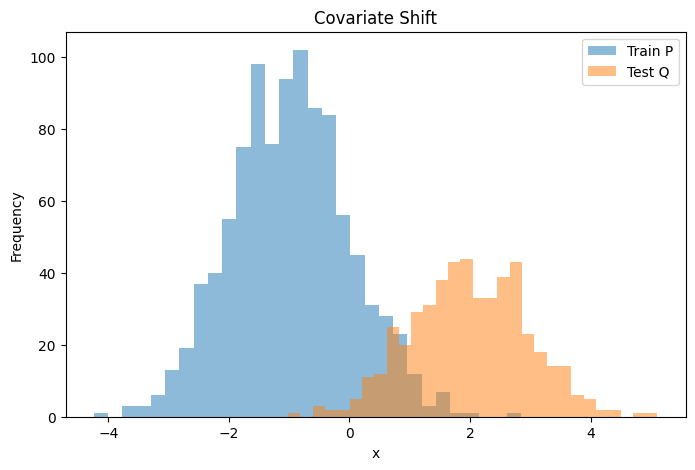

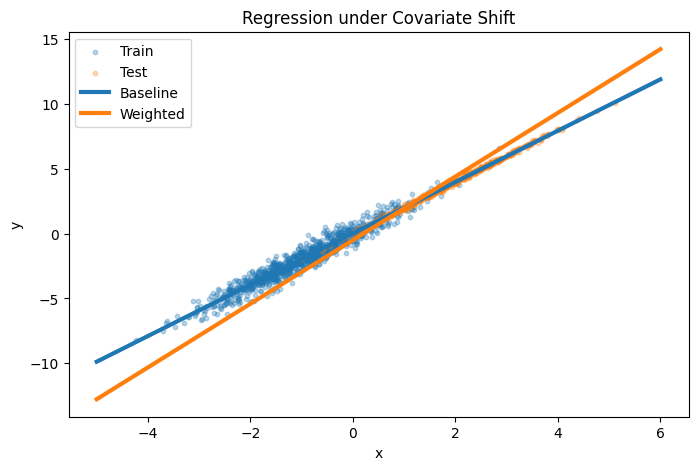

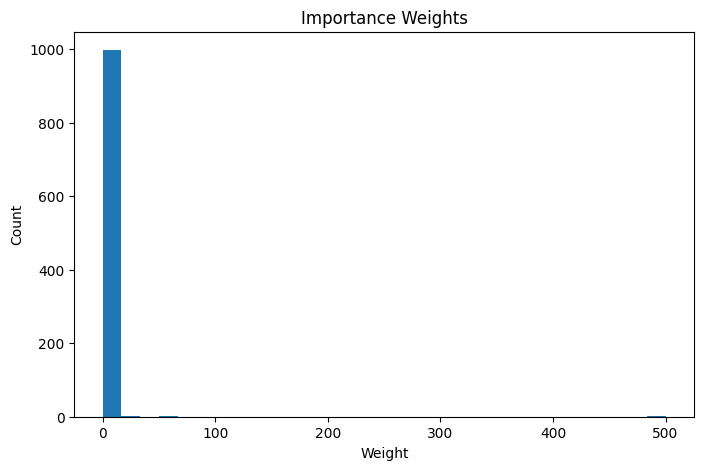

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

n_train = 1000
n_test = 500

x_train = np.random.normal(
    -1,
    1,
    n_train
).reshape(-1,1)

eps = np.random.normal(
    0,
    0.5,
    n_train
)

y_train = (
    2 * x_train.squeeze()
    + eps
)

x_test = np.random.normal(
    2,
    1,
    n_test
).reshape(-1,1)

eps_test = np.random.normal(
    0,
    0.1,
    n_test
)

y_test = (
    2 * x_test.squeeze()
    + eps_test
)

baseline = LinearRegression()

baseline.fit(
    x_train,
    y_train
)

pred_base = baseline.predict(
    x_test
)

mse_base = mean_squared_error(
    y_test,
    pred_base
)

print(
    'Baseline MSE:',
    mse_base
)

X_mix = np.vstack(
    [
        x_train,
        x_test
    ]
)

y_mix = np.hstack(
    [
        np.zeros(n_train),
        np.ones(n_test)
    ]
)

clf = LogisticRegression()

clf.fit(
    X_mix,
    y_mix
)

p_test = clf.predict_proba(
    x_train
)[:,1]

p_train = 1 - p_test

weights = (
    p_test
    /
    p_train
)

print(
    'Weight Mean:',
    weights.mean()
)

weighted_model = LinearRegression()

weighted_model.fit(
    x_train,
    y_train,
    sample_weight=weights
)

pred_weighted = weighted_model.predict(
    x_test
)

mse_weighted = mean_squared_error(
    y_test,
    pred_weighted
)

print(
    'Weighted MSE:',
    mse_weighted
)

plt.figure(figsize=(8,5))

plt.hist(
    x_train,
    bins=30,
    alpha=0.5,
    label='Train P'
)

plt.hist(
    x_test,
    bins=30,
    alpha=0.5,
    label='Test Q'
)

plt.legend()
plt.title(
    'Covariate Shift'
)
plt.xlabel('x')
plt.ylabel('Frequency')
plt.show()

x_plot = np.linspace(
    -5,
    6,
    200
).reshape(-1,1)

plt.figure(figsize=(8,5))

plt.scatter(
    x_train,
    y_train,
    s=10,
    alpha=0.3,
    label='Train'
)

plt.scatter(
    x_test,
    y_test,
    s=10,
    alpha=0.3,
    label='Test'
)

plt.plot(
    x_plot,
    baseline.predict(x_plot),
    linewidth=3,
    label='Baseline'
)

plt.plot(
    x_plot,
    weighted_model.predict(x_plot),
    linewidth=3,
    label='Weighted'
)

plt.legend()
plt.title(
    'Regression under Covariate Shift'
)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

plt.figure(figsize=(8,5))

plt.hist(
    weights,
    bins=30
)

plt.title(
    'Importance Weights'
)
plt.xlabel('Weight')
plt.ylabel('Count')
plt.show()